## Project summary

This project aims to identify the optimal investment opportunity within the Indian IT sector, employing a top-down analytical approach. Historical stock data for the Nifty50 index, key sectors, and individual IT companies was sourced from Yahoo Finance, covering a ten-year period from April 2016 to March 2026. The analysis progressed from macro-economic trends to specific company comparisons, ultimately concluding that Persistent Systems offers superior risk-adjusted returns, lower volatility, and stronger capital protection, making it the preferred investment choice.

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

## Macro aspect

In [ ]:
nifty50_ticker = yf.Ticker('^NSEI')

In [ ]:
nifty50_df = nifty50_ticker.history(start= '2016-04-01', end= '2026-03-31')

In [ ]:
if nifty50_df.empty:
  print("*****ERROR*****\nData not found!")
else:
  print(f"Dataset with {len(nifty50_df)} days of data has been successfully add")

Dataset with 2463 days of data has been successfully add


In [ ]:
nifty50_df.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2016-04-01 00:00:00+05:30,7718.049805,7740.149902,7666.100098,7713.049805,183900,0.0,0.0
2016-04-04 00:00:00+05:30,7733.149902,7764.450195,7704.399902,7758.799805,155500,0.0,0.0
2016-04-05 00:00:00+05:30,7736.299805,7736.299805,7588.649902,7603.200195,203800,0.0,0.0
2016-04-06 00:00:00+05:30,7636.049805,7638.649902,7591.750000,7614.350098,165600,0.0,0.0
2016-04-07 00:00:00+05:30,7630.399902,7630.750000,7535.850098,7546.450195,234400,0.0,0.0


In [ ]:
nifty50_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2463 entries, 2016-04-01 00:00:00+05:30 to 2026-03-30 00:00:00+05:30
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          2463 non-null   float64
 1   High          2463 non-null   float64
 2   Low           2463 non-null   float64
 3   Close         2463 non-null   float64
 4   Volume        2463 non-null   int64  
 5   Dividends     2463 non-null   float64
 6   Stock Splits  2463 non-null   float64
dtypes: float64(6), int64(1)
memory usage: 153.9 KB


In [ ]:
nifty50_df.describe()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,2463.000000,2463.000000,2463.000000,2463.000000,2.463000e+03,2463.0,2463.0
mean,15575.668679,15645.863333,15483.339173,15566.406367,3.418219e+05,0.0,0.0
std,5698.599175,5719.877081,5676.109243,5698.139916,1.902502e+05,0.0,0.0
min,7542.350098,7569.350098,7511.100098,7546.450195,0.000000e+00,0.0,0.0
25%,10644.949707,10696.750000,10586.225098,10626.049805,2.195000e+05,0.0,0.0
50%,14882.650391,14959.099609,14760.799805,14894.900391,2.847000e+05,0.0,0.0
75%,19644.225586,19722.025391,19563.024414,19662.299805,4.149000e+05,0.0,0.0
max,26333.699219,26373.199219,26210.050781,26328.550781,1.811000e+06,0.0,0.0


In [ ]:
nifty50_df.isnull().sum()

,0
Open,0
High,0
Low,0
Close,0
Volume,0
Dividends,0
Stock Splits,0


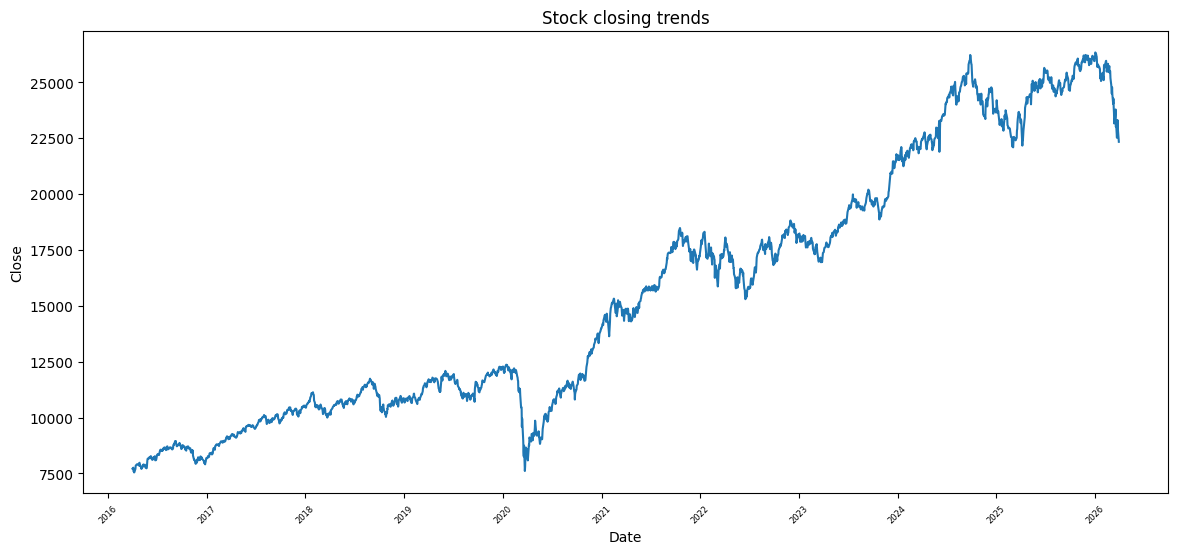

In [ ]:
plt.figure(figsize= (14,6))
plt.title('Stock closing trends')
sns.lineplot(x='Date', y='Close', data=nifty50_df)
plt.xticks(rotation=45, fontsize=6)
plt.show()

The pre pandemic, index value was between 7,500 to 12,500. Post pandemic it is between 15,000 to 25,000, an approximate of 2x grwoth.

This growth could mean any thing, new sectors, turn arounds or just a regular economic cycle. To find the exact reason we have to futher analyze this market and to strategicaly invest into.

#### Daily percentage changer

In [ ]:
nifty50_df['Returns'] = nifty50_df['Close'].pct_change()

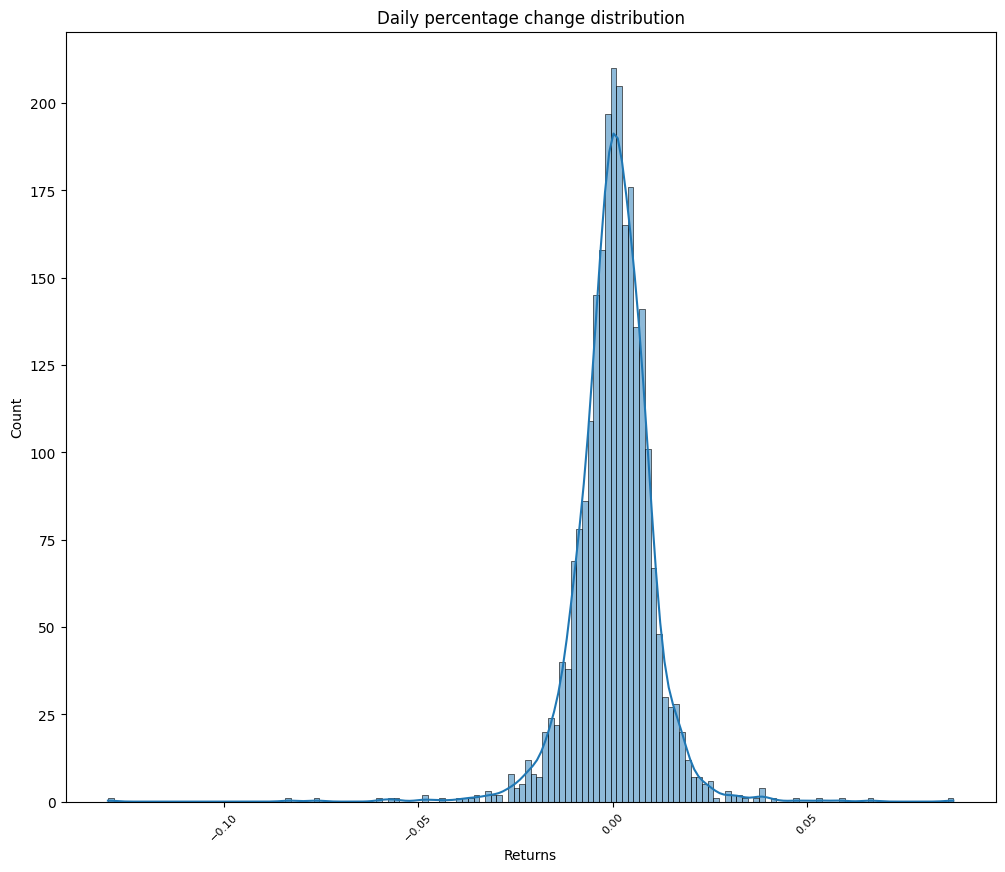

In [ ]:
plt.figure(figsize= (12,10))
plt.title('Daily percentage change distribution')
sns.histplot(data=nifty50_df, x='Returns', kde=True)
plt.xticks(rotation=45, fontsize=8)
plt.show()

#### Simple movind average

In [ ]:
nifty50_df['SMA50'] = nifty50_df['Close'].rolling(window=50).mean()
nifty50_df['SMA200'] = nifty50_df['Close'].rolling(window=200).mean()

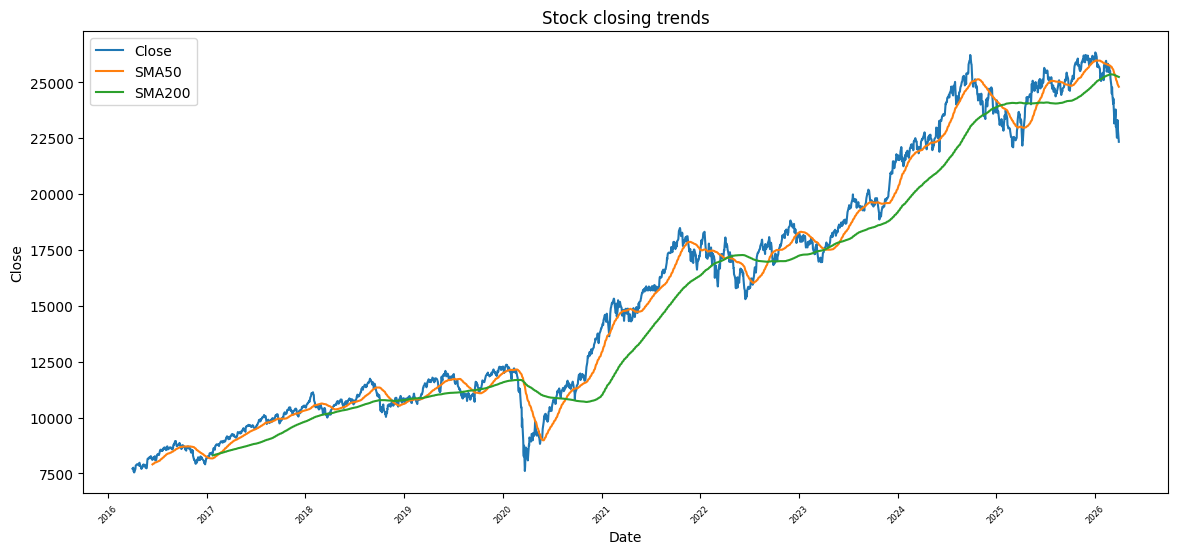

In [ ]:
plt.figure(figsize= (14,6))
plt.title('Stock closing trends')
sns.lineplot(x='Date', y='Close', data=nifty50_df, label='Close')
sns.lineplot(x='Date', y='SMA50', data=nifty50_df, label='SMA50')
sns.lineplot(x='Date', y='SMA200', data=nifty50_df, label='SMA200')
plt.xticks(rotation=45, fontsize=6)
plt.show()

After comparing SMA50 (yellow line) with SMA200 (green line) we can see that SMA50 goes above SMA200 creating a crossover. This has happend multiple times in the past decade, some happend in mid 2020, early 2023 and early 2025. This signalls to a bullish trend, meaning high investor confidence and strong economic growth.

#### Annualized Volatility

In [ ]:
nifty50_df['rolling_std'] = nifty50_df['Returns'].rolling(window=30).std()

In [ ]:
trading_days_per_year = 252
nifty50_df['annualized_volatility'] = nifty50_df['rolling_std'] * np.sqrt(trading_days_per_year)

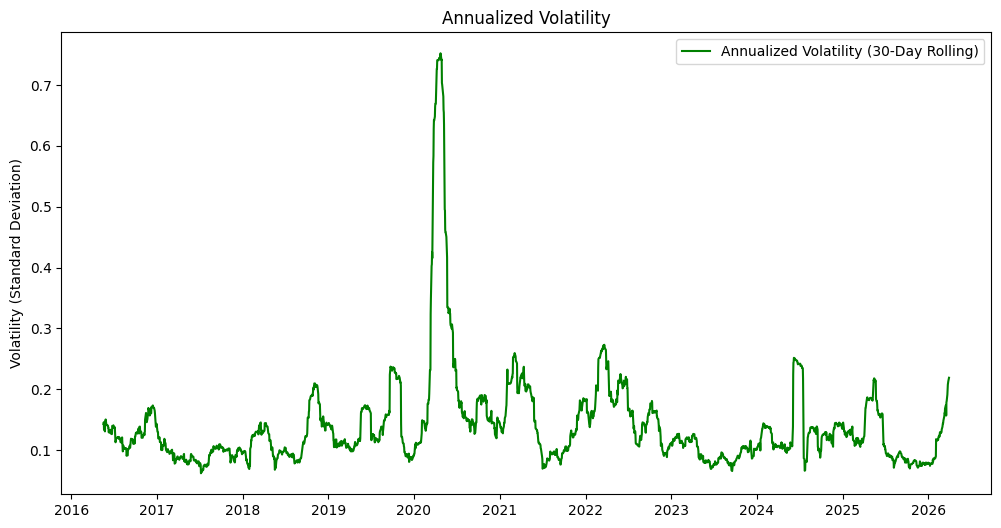

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(nifty50_df['annualized_volatility'] , label= 'Annualized Volatility (30-Day Rolling)', color='green')
plt.title('Annualized Volatility')
plt.ylabel('Volatility (Standard Deviation)')
plt.legend()
plt.show()

Volatility check how rapidly the prices goes up and down. A high volatility number indicates rapid changes (high risk), while a low indicates low changes (less risk). We see a large spike around march 2020, this is due to the pandemic.

#### sharpe ration

In [ ]:
annual_daily_return = nifty50_df['Returns'].mean() * 252

In [ ]:
sharpe_ration = (annual_daily_return - 0.0691) / nifty50_df['annualized_volatility'].mean()
print(f"Sharpe Ratio: {sharpe_ration:.4f}")

Sharpe Ratio: 0.3808


A Sharpe of 0.38 indicates the Nifty50 delivered modest risk-adjusted returns over this period, the market generated returns above the risk-free rate, but not by a wide margin relative to its volatility

#### Maximum drawdown

In [ ]:
# 1. Calculate the running maximum (the highest point reached so far)
nifty50_df['Peak'] = nifty50_df['Close'].cummax()

# 2. Calculate the drawdown percentage
nifty50_df['Drawdown'] = (nifty50_df['Close'] - nifty50_df['Peak']) / nifty50_df['Peak']

# 3. Find the Maximum Drawdown
max_drawdown = nifty50_df['Drawdown'].min()
print(f"Maximum Drawdown: {max_drawdown * 100:.2f}%")

Maximum Drawdown: -38.44%


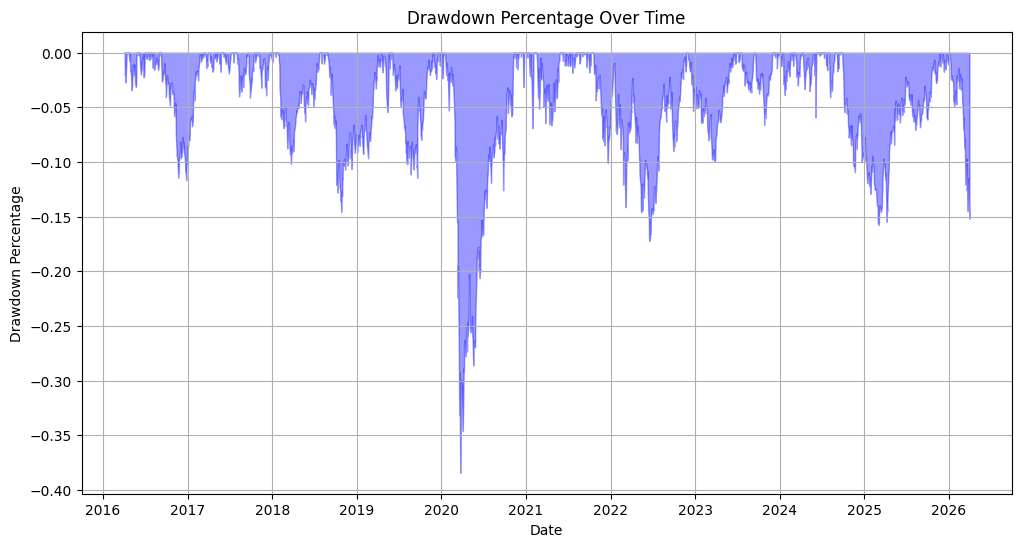

In [ ]:
plt.figure(figsize=(12,6))
plt.fill_between(nifty50_df.index, nifty50_df['Drawdown'], color='blue', alpha=0.4)
plt.title('Drawdown Percentage Over Time')
plt.xlabel('Date')
plt.ylabel('Drawdown Percentage')
plt.grid(True)
plt.show()

The maximum drawdown of -38% occurred during the Covid crash of March 2020. Post-pandemic, drawdowns have remained below -20%, reflecting a more stable market environment. However, the -38% figure remains the relevant worst-case risk benchmark for this investment period.

## Transition from macro to micro

After analyzing the market I want to check which sector is getting better or contributing the most to the market.

In [2]:
tickers = ["^NSEI", "^CNXIT", "^NSEBANK", "^CNXAUTO", "^CNXFMCG", "^CNXPHARMA"]

# Initialize an empty list to store the 'Close' price Series for each ticker
close_prices = []

for ticker_symbol in tickers:
    nifty50_sector_ticker = yf.Ticker(ticker_symbol)
    # Get historical 'Close' data and rename the column to the ticker symbol
    sector_df = nifty50_sector_ticker.history(start='2016-04-01', end='2026-03-31')[['Close']]
    sector_df = sector_df.rename(columns={'Close': ticker_symbol})
    close_prices.append(sector_df)

# Concatenate all individual DataFrames into a single DataFrame
# using the 'Date' index to align them
nifty50_sector_df = pd.concat(close_prices, axis=1)

# Display the head of the combined DataFrame to verify
display(nifty50_sector_df.head())

,^NSEI,^CNXIT,^NSEBANK,^CNXAUTO,^CNXFMCG,^CNXPHARMA
Date,,,,,,
2016-04-01 00:00:00+05:30,7713.049805,11194.650391,16174.711914,8030.049805,19992.099609,10928.299805
2016-04-04 00:00:00+05:30,7758.799805,11387.700195,16190.411133,8124.549805,19890.599609,10978.000000
2016-04-05 00:00:00+05:30,7603.200195,11274.950195,15694.817383,7883.100098,19635.400391,10876.900391
2016-04-06 00:00:00+05:30,7614.350098,11224.950195,15636.768555,7919.950195,19657.550781,10905.549805
2016-04-07 00:00:00+05:30,7546.450195,11102.599609,15530.569336,7834.600098,19384.050781,10984.349609


In [ ]:
nifty50_sector_df.shape

(2466, 6)

In [ ]:
nifty50_sector_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2466 entries, 2016-04-01 00:00:00+05:30 to 2026-03-30 00:00:00+05:30
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ^NSEI       2463 non-null   float64
 1   ^CNXIT      2465 non-null   float64
 2   ^NSEBANK    2465 non-null   float64
 3   ^CNXAUTO    2450 non-null   float64
 4   ^CNXFMCG    2449 non-null   float64
 5   ^CNXPHARMA  2464 non-null   float64
dtypes: float64(6)
memory usage: 134.9 KB


In [ ]:
nifty50_sector_df.describe()

,^NSEI,^CNXIT,^NSEBANK,^CNXAUTO,^CNXFMCG,^CNXPHARMA
count,2463.000000,2465.000000,2465.000000,2450.000000,2449.000000,2464.000000
mean,15566.406367,24152.567875,35247.719269,13484.808961,38139.241957,13421.850935
std,5698.139916,10735.343348,12086.077306,6240.989471,12429.347480,4755.956164
min,7546.450195,9434.599609,15530.569336,4517.750000,19295.849609,6432.299805
25%,10626.049805,14108.400391,25184.056641,9146.974854,28673.699219,9501.762207
50%,14894.900391,26010.849609,33317.812500,10951.700195,34411.648438,12270.349609
75%,19662.299805,34409.398438,44584.550781,16027.387695,51713.000000,15236.537354
max,26328.550781,45995.800781,61550.800781,28922.349609,66305.203125,23783.800781


In [ ]:
nifty50_sector_df.isnull().sum()

,0
^NSEI,3
^CNXIT,1
^NSEBANK,1
^CNXAUTO,16
^CNXFMCG,17
^CNXPHARMA,2


#### Handling Missing Values

Given the time-series nature of stock data, simple dropping or median imputation can distort the data's integrity. A more appropriate approach is to use forward fill, followed by linear interpolation. This preserves the temporal sequence and estimates missing values based on adjacent known values.

In [3]:
# Apply forward fill to carry forward the last valid observation
nifty50_sector_df_filled = nifty50_sector_df.ffill()

# Apply linear interpolation to fill any remaining NaNs (e.g., at the beginning of the series)
nifty50_sector_df_filled = nifty50_sector_df_filled.interpolate(method='linear')

# Check for any remaining null values after imputation
print("Missing values after ffill and interpolate:")
nifty50_sector_df_filled.isnull().sum()

Missing values after ffill and interpolate:


,0
^NSEI,0
^CNXIT,0
^NSEBANK,0
^CNXAUTO,0
^CNXFMCG,0
^CNXPHARMA,0


In [4]:
nifty50_sector_df_normalized = (nifty50_sector_df_filled / nifty50_sector_df_filled.iloc[0]) * 100 # normalized

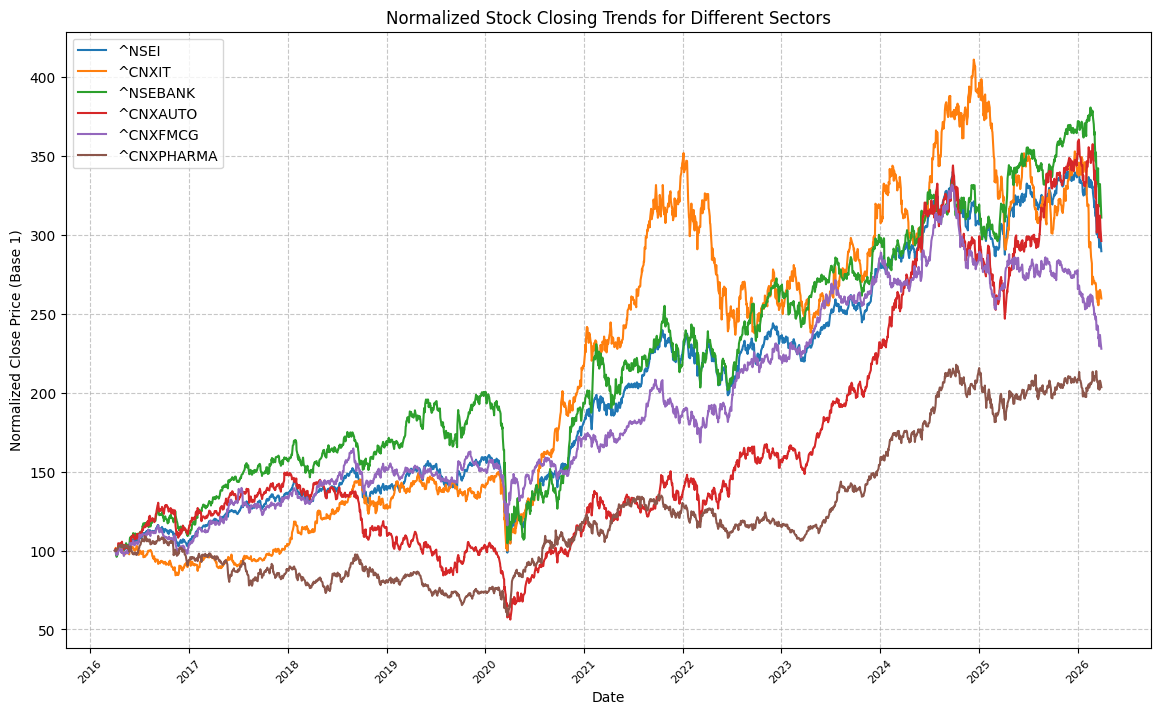

In [ ]:
plt.figure(figsize=(14, 8))
plt.title('Normalized Stock Closing Trends for Different Sectors')

for column in nifty50_sector_df_normalized.columns:
    sns.lineplot(x=nifty50_sector_df_normalized.index, y=nifty50_sector_df_normalized[column], label=column)

plt.xlabel('Date')
plt.ylabel('Normalized Close Price (Base 1)')
plt.xticks(rotation=45, fontsize=8)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

I have normalized the data for better comparision. In the above plot we can see that IT sector had a turnaround during pandemic. While other sectors were growing, the IT sector became the strongest outperformer in this peer group on a normalized basis, surpassing Banking, Auto, FMCG, and Pharma by 2022. Curently we see that the sector has become much more mature and is growing at the same pase as oter sectors, like banking auto and FMCG, which were prominend sectors in this market.

#### Correlation

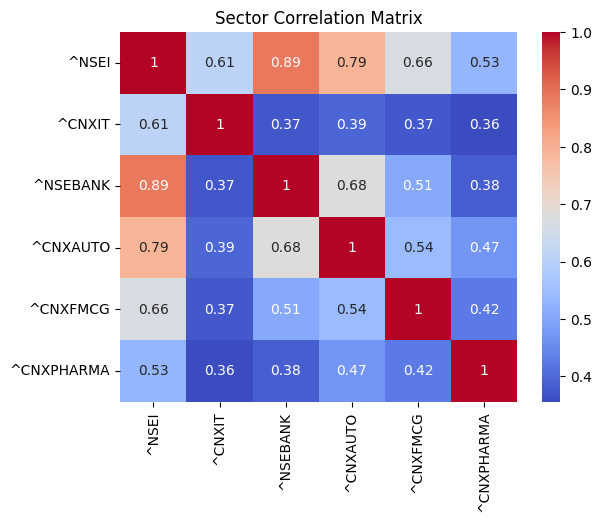

In [ ]:
# Calculate correlation of daily returns
returns = nifty50_sector_df_filled.pct_change().dropna()
correlation_matrix = returns.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Sector Correlation Matrix")
plt.show()

Banking and Auto show the highest correlation with each other, suggesting they respond to similar macroeconomic factors. And on the other side, IT has weak correaltion with all the other industries in this group.

#### Sector Rotation Analysis

Sector rotation is an investment strategy that involves shifting investment capital from one sector of the economy to another in an attempt to outperform the market. The idea is that different sectors perform better at different stages of the economic cycle. Identifying a 'turnaround' in a sector means recognizing when its relative performance begins to improve compared to the overall market or other sectors.

To analyze this, we'll typically look at the cumulative returns of each sector relative to a benchmark (like the NIFTY50 index itself). When a sector's relative performance starts trending upwards, it could signal a turnaround.

In [ ]:
# Calculate daily returns for all sectors
daily_returns = nifty50_sector_df_filled.pct_change().dropna()

# Calculate cumulative returns for each sector and the NIFTY50 index (^NSEI)
# We'll add 1 to the daily returns before cumulative product to correctly reflect growth
cumulative_returns = (1 + daily_returns).cumprod()

# Display the head of the cumulative returns to verify
print("Cumulative Returns:")
display(cumulative_returns.head())

Cumulative Returns:


,^NSEI,^CNXIT,^NSEBANK,^CNXAUTO,^CNXFMCG,^CNXPHARMA
Date,,,,,,
2016-04-04 00:00:00+05:30,1.005932,1.017245,1.000971,1.011768,0.994923,1.004548
2016-04-05 00:00:00+05:30,0.985758,1.007173,0.970331,0.981700,0.982158,0.995297
2016-04-06 00:00:00+05:30,0.987204,1.002707,0.966742,0.986289,0.983266,0.997918
2016-04-07 00:00:00+05:30,0.978400,0.991777,0.960176,0.975660,0.969586,1.005129
2016-04-08 00:00:00+05:30,0.979535,0.988075,0.962501,0.974004,0.972969,1.007705


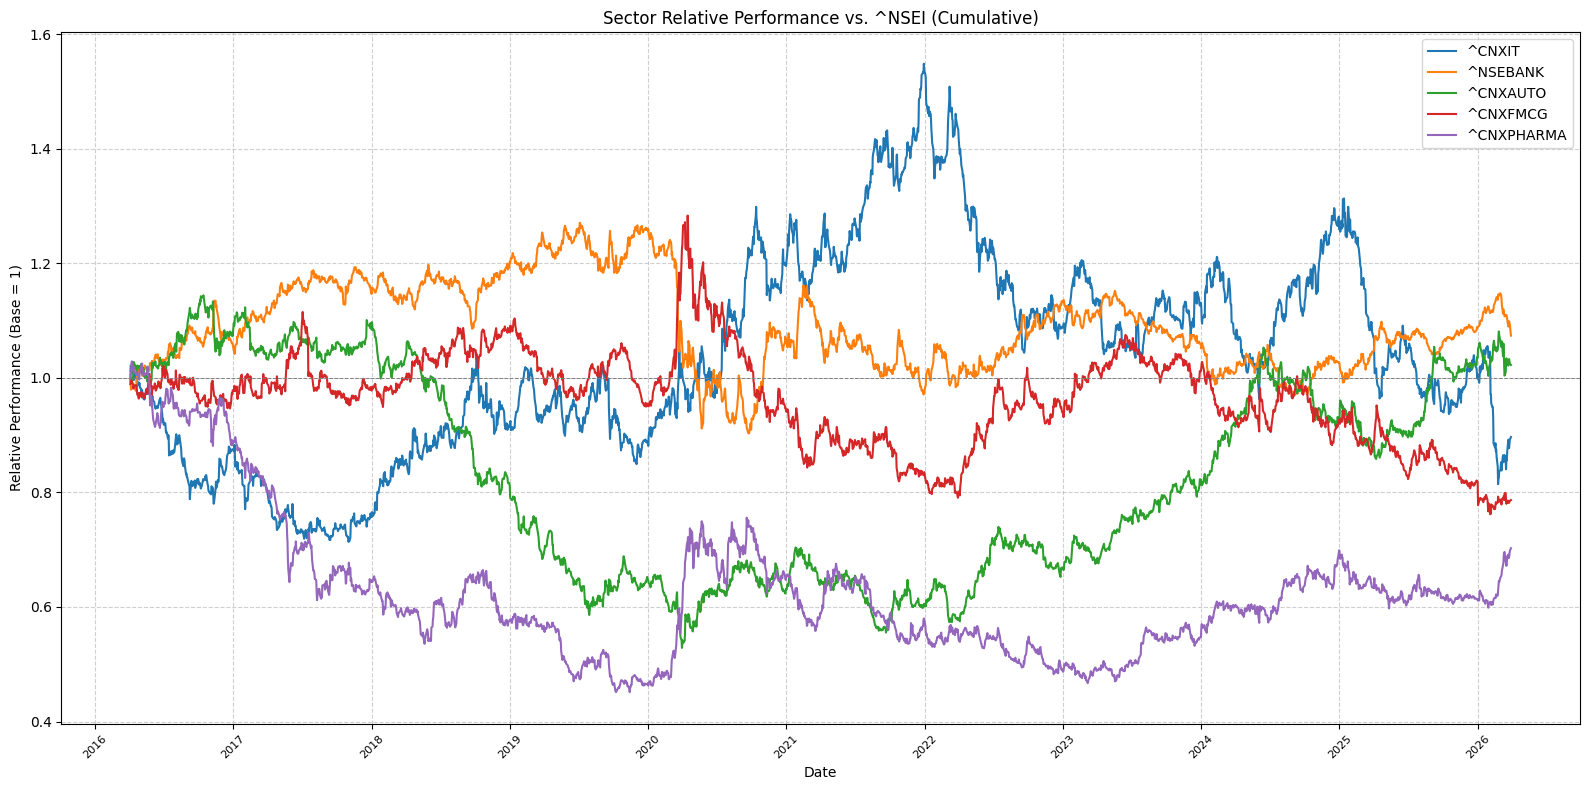


Interpretation: A line trending upwards indicates the sector is outperforming ^NSEI,
while a downward trend means underperformance. A turnaround would be visible as a change
from a downward to an upward trend.


In [ ]:
# Calculate relative performance against the overall NIFTY50 index (^NSEI)
# Divide each sector's cumulative return by the cumulative return of ^NSEI
relative_performance = cumulative_returns.divide(cumulative_returns['^NSEI'], axis=0)

# Plotting the relative performance
plt.figure(figsize=(16, 8))
for column in relative_performance.columns:
    if column != '^NSEI': # Don't plot NIFTY50 against itself, as it would be a flat line at 1
        sns.lineplot(x=relative_performance.index, y=relative_performance[column], label=column)

plt.title('Sector Relative Performance vs. ^NSEI (Cumulative)')
plt.xlabel('Date')
plt.ylabel('Relative Performance (Base = 1)')
plt.axhline(y=1, color='gray', linestyle='--', linewidth=0.7, label='Benchmark (^NSEI)')
plt.xticks(rotation=45, fontsize=8)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("\nInterpretation: A line trending upwards indicates the sector is outperforming ^NSEI,\nwhile a downward trend means underperformance. A turnaround would be visible as a change\nfrom a downward to an upward trend.")

The blue line indicates the IT sector and the line a 0.0 represents the nifty50 index. The IT sector is outperforming the nigty50 index and it's also outperforming many of the other sectors from 2021 to 2025. In the first quarter of 2026, IT sector is underperforming and other sectors like auto and banking has risen up.

But there is a trend in the IT sector. Beginning of every year the market goes down and then it goes up around april - june. And we are seeing a increasing trend in the last few days on 2026. A potential seasonal pattern is visible in the chart, though a formal seasonality analysis would be needed to confirm this.

For years the banking, FMCG and auto was give the best return, but in the past few years the IT sector had caught up and somoetimes outpermorfs those sectors. From the analysis we have done till now suggests that the market prices for the IT sector will goes up. So to get more returns from investment it would be a good idea to inverst in the IT sector.

## Micro aspects

To further understand which company to invest in the IT sector we need to figure our which company is performing better than its competitors. Here is a list of top companies in this sector.

| Company       | Listed on NSE | Safe for this project |
|---------------|---------------|-----------------------|
| TCS           | 200           | Yes                   |
| Infosys       | 1993          | Yes                   |
| Wipro         | 1945          | Yes                   |
| HCL Tech      | 1999          | Yes                   |
| Tech Mahindra | 2006          | Yes                   |
| LTIMindtree   | 2022 (merger) | No (LTIM + Mindtree separately or skip)|
| Mphasis       | 2004          | Yes                   |
| Persistent Systems | 2010     | Yes                   |
| Coforge       | 2004 (as NIIT Tech) | Partial — ticker changed |
| L&T Technology| 2016          |Borderline — IPO was Sept 2016 |

For comparision I will be excluding LTMMidtree as they merged (previously LTM and Mindtree were seperate companies) and L&T Technologies as they became public in 2016, so getting their past data is dificult.

In [5]:
new_tickers = ["TCS.NS", "INFY.NS", "WIPRO.NS", "TECHM.NS", "HCLTECH.NS", "MPHASIS.NS", "PERSISTENT.NS", "COFORGE.NS"]

# Initialize an empty list to store the 'Close' price Series for each ticker
it_close_prices = []

for new_ticker_symbol in new_tickers:
    nifty_it = yf.Ticker(new_ticker_symbol)
    # Get historical 'Close' data and rename the column to the ticker symbol
    it_sector_df = nifty_it.history(start='2016-04-01', end='2026-03-31')[['Close']]
    it_sector_df = it_sector_df.rename(columns={'Close': new_ticker_symbol})
    it_close_prices.append(it_sector_df)

# Concatenate all individual DataFrames into a single DataFrame
# using the 'Date' index to align them
nifty_it_df = pd.concat(it_close_prices, axis=1)

nifty_it_df.head()

,TCS.NS,INFY.NS,WIPRO.NS,TECHM.NS,HCLTECH.NS,MPHASIS.NS,PERSISTENT.NS,COFORGE.NS
Date,,,,,,,,
2016-04-01 00:00:00+05:30,970.581726,460.079437,95.593880,334.228790,310.924377,360.034424,332.890808,86.068291
2016-04-04 00:00:00+05:30,977.444031,474.678162,96.291084,339.605621,318.295715,349.541260,337.450104,88.152466
2016-04-05 00:00:00+05:30,974.082458,465.556396,95.058212,333.615326,319.584381,352.039581,335.720703,85.790390
2016-04-06 00:00:00+05:30,981.656189,458.266479,94.922188,326.939423,317.878845,354.076721,331.969971,85.095673
2016-04-07 00:00:00+05:30,977.265930,450.938507,93.833862,320.768768,313.975281,356.920990,326.310272,85.616714


In [ ]:
nifty_it_df.shape

(2469, 8)

In [ ]:
nifty_it_df.describe()

,TCS.NS,INFY.NS,WIPRO.NS,TECHM.NS,HCLTECH.NS,MPHASIS.NS,PERSISTENT.NS,COFORGE.NS
count,2469.000000,2469.000000,2469.000000,2469.000000,2469.000000,2469.000000,2469.000000,2469.000000
mean,2394.729957,1027.651012,171.484569,870.984073,826.317275,1575.937031,1897.818138,672.575414
std,978.787243,490.710378,70.041339,430.585821,471.814720,906.784387,1964.381353,541.099840
min,844.116516,346.069702,74.470161,278.204132,270.814514,349.541260,221.803650,69.435364
25%,1579.796509,551.219971,101.721474,500.140137,388.839722,756.309204,300.167511,207.929886
50%,2694.899902,1170.297852,178.880493,833.175964,784.621643,1522.236450,930.907654,540.538940
75%,3169.600098,1458.691284,234.915070,1234.526733,1148.678101,2410.801270,2848.895020,1024.404053
max,4311.585449,1942.221191,333.296661,1768.400024,1908.191406,3246.188477,6610.561523,1973.185425


In [ ]:
nifty_it_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2469 entries, 2016-04-01 00:00:00+05:30 to 2026-03-30 00:00:00+05:30
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   TCS.NS         2469 non-null   float64
 1   INFY.NS        2469 non-null   float64
 2   WIPRO.NS       2469 non-null   float64
 3   TECHM.NS       2469 non-null   float64
 4   HCLTECH.NS     2469 non-null   float64
 5   MPHASIS.NS     2469 non-null   float64
 6   PERSISTENT.NS  2469 non-null   float64
 7   COFORGE.NS     2469 non-null   float64
dtypes: float64(8)
memory usage: 173.6 KB


In [ ]:
nifty_it_df.isnull().sum()

,0
TCS.NS,0
INFY.NS,0
WIPRO.NS,0
TECHM.NS,0
HCLTECH.NS,0
MPHASIS.NS,0
PERSISTENT.NS,0
COFORGE.NS,0


#### Cumulative Returns for IT Companies (Normalized Comparison)

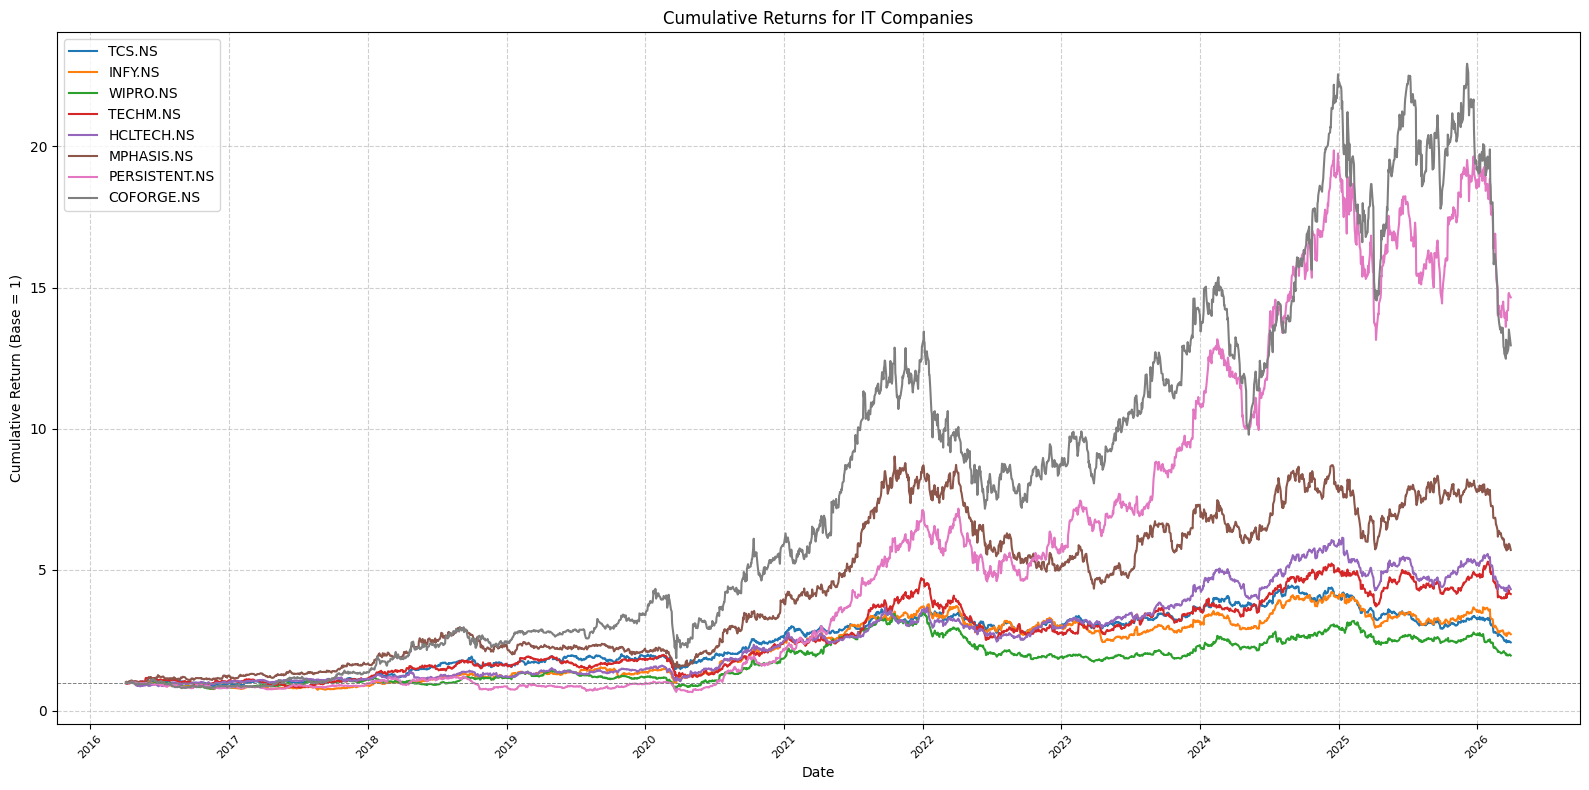

In [ ]:
# Calculate daily returns for all IT companies
it_daily_returns = nifty_it_df.pct_change().dropna()

# Calculate cumulative returns for each IT company
# Add 1 to daily returns before cumulative product to correctly reflect growth
it_cumulative_returns = (1 + it_daily_returns).cumprod()

# Plotting the cumulative returns
plt.figure(figsize=(16, 8))
for column in it_cumulative_returns.columns:
    sns.lineplot(x=it_cumulative_returns.index, y=it_cumulative_returns[column], label=column)

plt.title('Cumulative Returns for IT Companies')
plt.xlabel('Date')
plt.ylabel('Cumulative Return (Base = 1)')
plt.axhline(y=1, color='gray', linestyle='--', linewidth=0.7, label='Starting Point')
plt.xticks(rotation=45, fontsize=8)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

After normalization, both Coforge and Persistent systems are performing better than others. Unlike, lets say TCS or Infosys, they are smaller companies compared to them.

For our portfolio we will be comparing these two companies to see which is a good company to invest.

#### Comparing Coforge and Persistent Systems

In [6]:
# Define the specific tickers for comparison
compare_tickers = ["COFORGE.NS", "PERSISTENT.NS"]

# Create a new DataFrame with only the selected companies from the original IT companies data
compare_stock_df = nifty_it_df[compare_tickers].copy()

compare_stock_df.head()

,COFORGE.NS,PERSISTENT.NS
Date,,
2016-04-01 00:00:00+05:30,86.068291,332.890808
2016-04-04 00:00:00+05:30,88.152466,337.450104
2016-04-05 00:00:00+05:30,85.790390,335.720703
2016-04-06 00:00:00+05:30,85.095673,331.969971
2016-04-07 00:00:00+05:30,85.616714,326.310272


In [10]:
# Calculate daily percentage change for the selected companies
for ticker in compare_tickers:
    compare_stock_df[f'Returns_{ticker.split(".")[0]}'] = compare_stock_df[ticker].pct_change()

compare_stock_df.head()

,COFORGE.NS,PERSISTENT.NS,Returns_COFORGE,Returns_PERSISTENT
Date,,,,
2016-04-01 00:00:00+05:30,86.068291,332.890808,NaN,NaN
2016-04-04 00:00:00+05:30,88.152466,337.450104,0.024215,0.013696
2016-04-05 00:00:00+05:30,85.790390,335.720703,-0.026795,-0.005125
2016-04-06 00:00:00+05:30,85.095673,331.969971,-0.008098,-0.011172
2016-04-07 00:00:00+05:30,85.616714,326.310272,0.006123,-0.017049


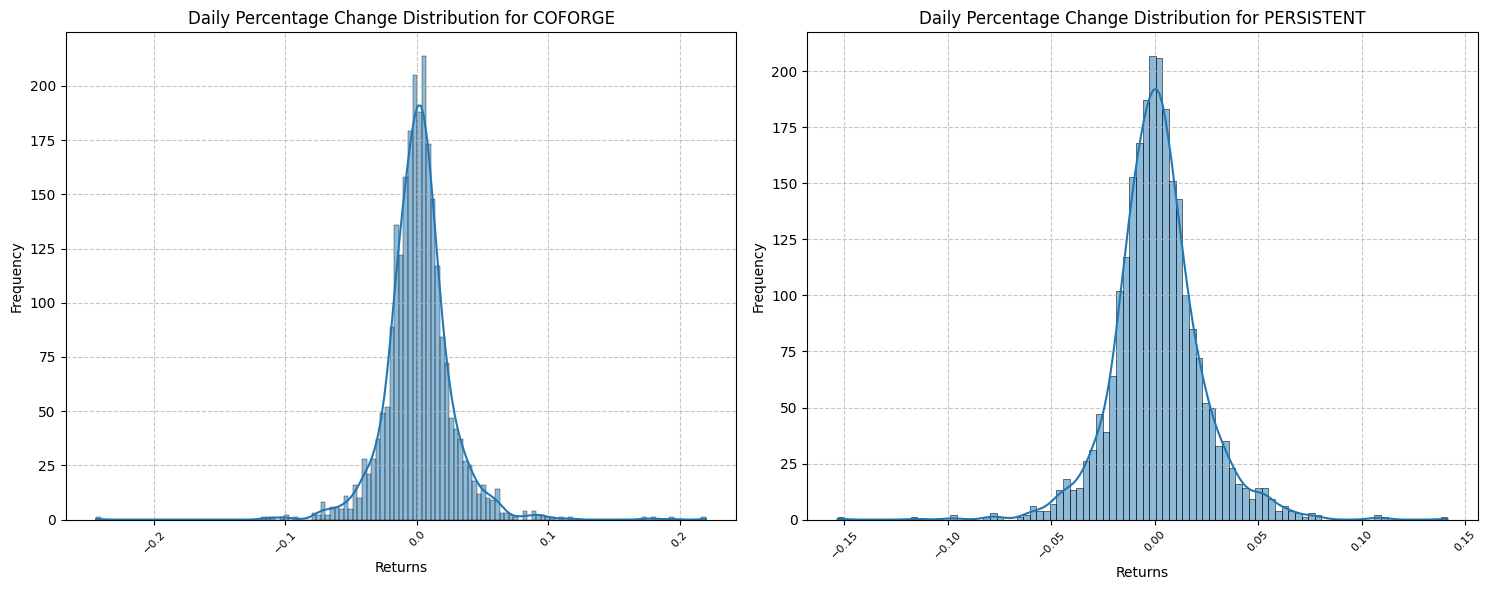

In [11]:
plt.figure(figsize=(15, 6))

# Get all columns that start with 'Returns_'
return_columns = [col for col in compare_stock_df.columns if col.startswith('Returns_')]

for i, col in enumerate(return_columns):
    plt.subplot(1, len(return_columns), i + 1) # Create subplots for each company
    sns.histplot(data=compare_stock_df, x=col, kde=True, label=col)
    plt.title(f'Daily Percentage Change Distribution for {col.replace("Returns_", "")}')
    plt.xlabel('Returns')
    plt.ylabel('Frequency')
    plt.xticks(rotation=45, fontsize=8)
    plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Both distributions show a roughly bell-shaped curve centred near zero, consistent with normal market behaviour. The tails, representing extreme daily gains or losses, are slightly fatter than a perfect normal distribution, which is typical of equity returns and indicates occasional large moves in either direction.

#### Simple Moving Average (SMA)

In [12]:
# Calculate SMA for COFORGE.NS and PERSISTENT.NS
for ticker in compare_tickers:
    company_name = ticker.split('.')[0]
    compare_stock_df[f'SMA50_{company_name}'] = compare_stock_df[ticker].rolling(window=50).mean()
    compare_stock_df[f'SMA200_{company_name}'] = compare_stock_df[ticker].rolling(window=200).mean()

display(compare_stock_df.head())

,COFORGE.NS,PERSISTENT.NS,Returns_COFORGE,Returns_PERSISTENT,SMA50_COFORGE,SMA200_COFORGE,SMA50_PERSISTENT,SMA200_PERSISTENT
Date,,,,,,,,
2016-04-01 00:00:00+05:30,86.068291,332.890808,NaN,NaN,NaN,NaN,NaN,NaN
2016-04-04 00:00:00+05:30,88.152466,337.450104,0.024215,0.013696,NaN,NaN,NaN,NaN
2016-04-05 00:00:00+05:30,85.790390,335.720703,-0.026795,-0.005125,NaN,NaN,NaN,NaN
2016-04-06 00:00:00+05:30,85.095673,331.969971,-0.008098,-0.011172,NaN,NaN,NaN,NaN
2016-04-07 00:00:00+05:30,85.616714,326.310272,0.006123,-0.017049,NaN,NaN,NaN,NaN


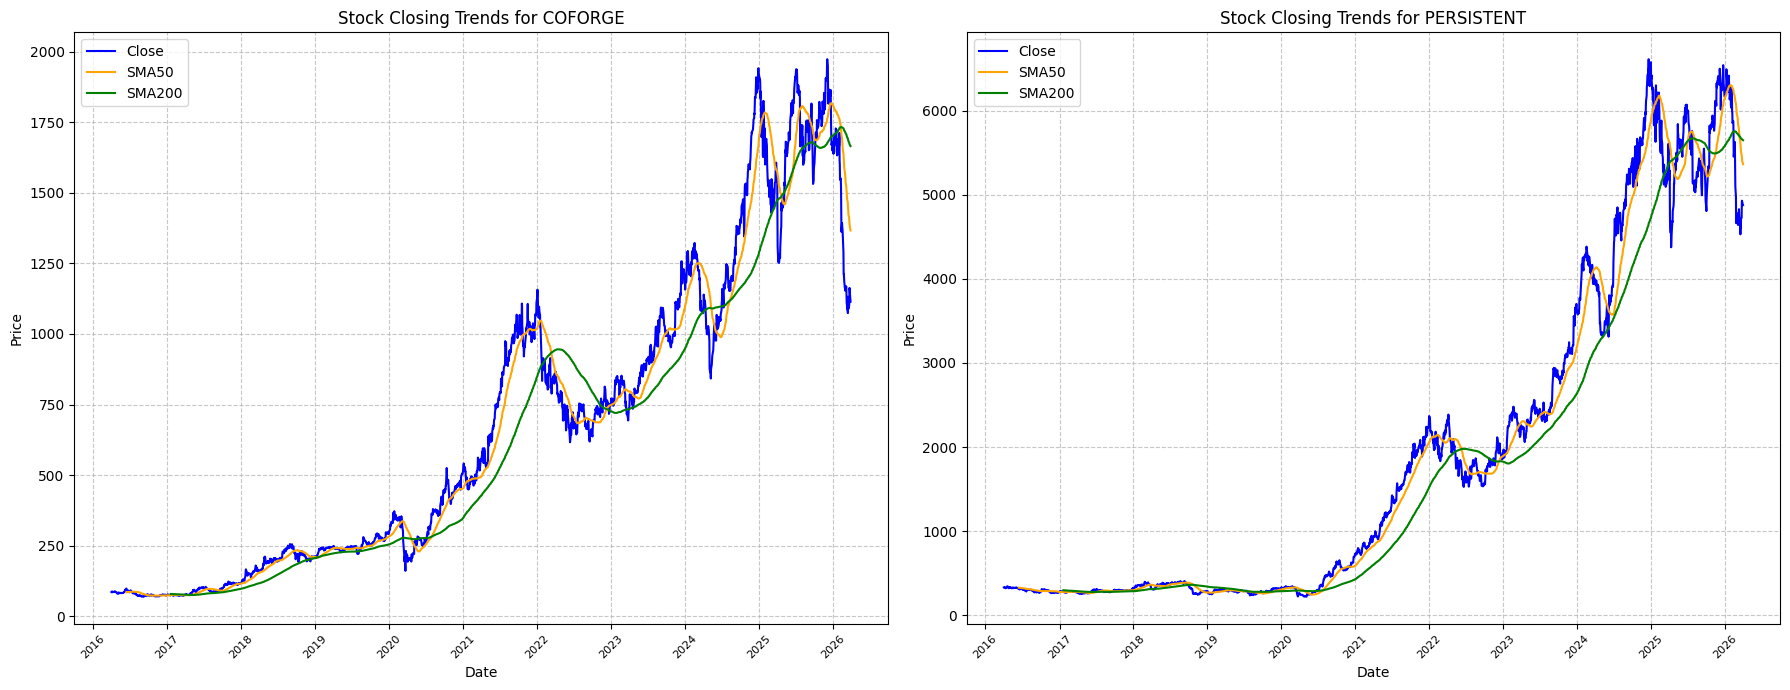

In [13]:
plt.figure(figsize=(18, 7))

for i, ticker in enumerate(compare_tickers):
    company_name = ticker.split('.')[0]
    plt.subplot(1, len(compare_tickers), i + 1)
    sns.lineplot(x=compare_stock_df.index, y=compare_stock_df[ticker], label='Close', color='blue')
    sns.lineplot(x=compare_stock_df.index, y=compare_stock_df[f'SMA50_{company_name}'], label='SMA50', color='orange')
    sns.lineplot(x=compare_stock_df.index, y=compare_stock_df[f'SMA200_{company_name}'], label='SMA200', color='green')
    plt.title(f'Stock Closing Trends for {company_name}')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.xticks(rotation=45, fontsize=8)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Similar to the nifty50 market analysis. We see the bullish trend happening multiple times. In recent months, SMA50 has fallen below SMA200 for both companies, forming a death cross. This is a bearish technical signal indicating short-term downward momentum, consistent with the broader IT sector correction visible in the macro analysis.

#### Volatility

In [15]:
for ticker in compare_tickers:
  company_name = ticker.split('.')[0]
  compare_stock_df[f'rolling_std_{company_name}'] = compare_stock_df[f'Returns_{company_name}'].rolling(window=30).std()

In [16]:
trading_days_per_year = 252

for i, ticker in enumerate(compare_tickers):
  company_name = ticker.split('.')[0]
  compare_stock_df[f'annualized_volatility_{company_name}'] = compare_stock_df[f'rolling_std_{company_name}'] * np.sqrt(trading_days_per_year)

compare_stock_df.head()

,COFORGE.NS,PERSISTENT.NS,Returns_COFORGE,Returns_PERSISTENT,SMA50_COFORGE,SMA200_COFORGE,SMA50_PERSISTENT,SMA200_PERSISTENT,rolling_std_COFORGE,rolling_std_PERSISTENT,annualized_volatility_COFORGE,annualized_volatility_PERSISTENT
Date,,,,,,,,,,,,
2016-04-01 00:00:00+05:30,86.068291,332.890808,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-04-04 00:00:00+05:30,88.152466,337.450104,0.024215,0.013696,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-04-05 00:00:00+05:30,85.790390,335.720703,-0.026795,-0.005125,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-04-06 00:00:00+05:30,85.095673,331.969971,-0.008098,-0.011172,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-04-07 00:00:00+05:30,85.616714,326.310272,0.006123,-0.017049,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


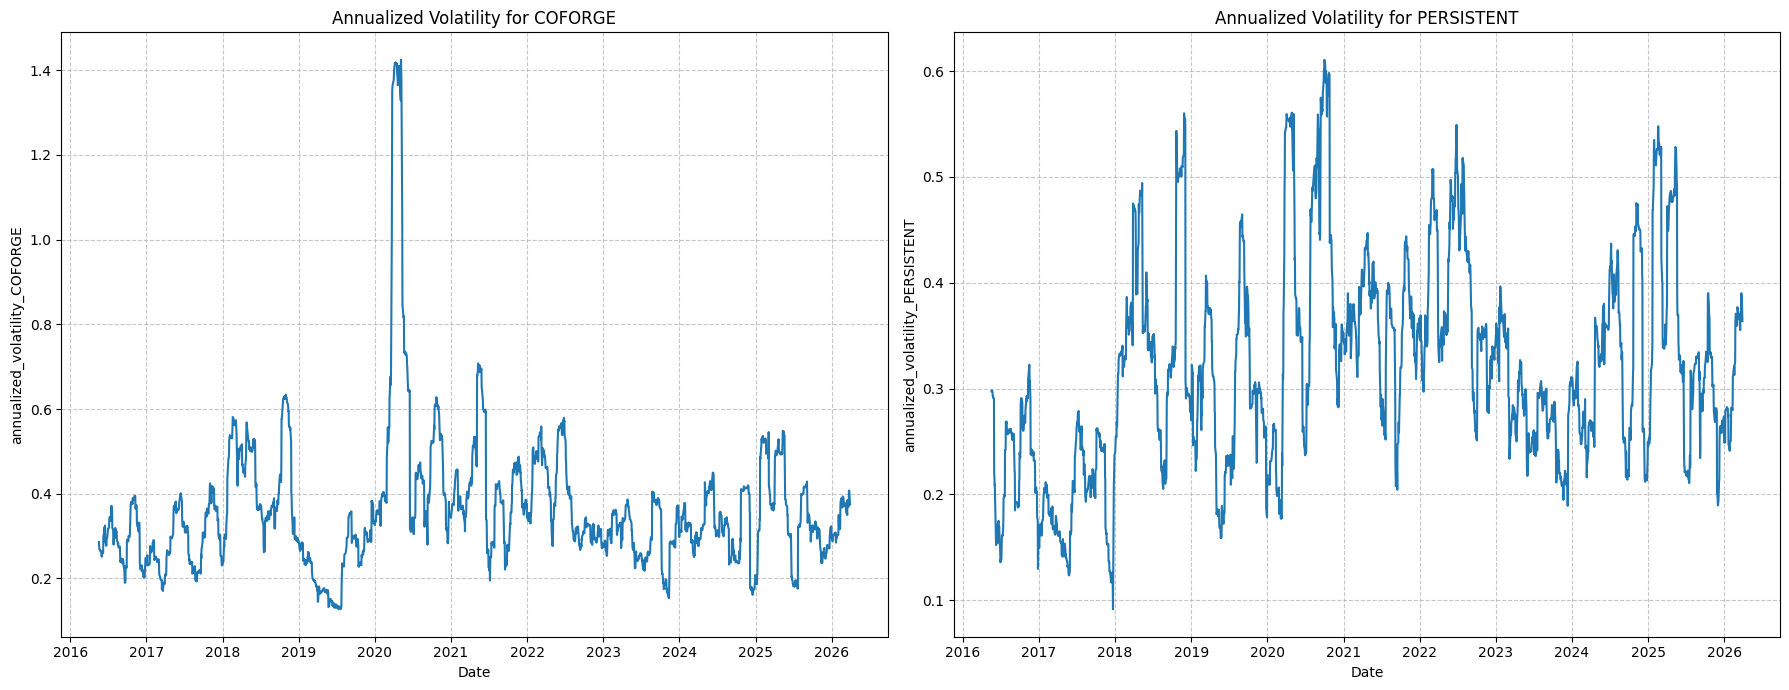

In [17]:
plt.figure(figsize= (18,7))

for i, ticker in enumerate(compare_tickers):
  company_name = ticker.split('.')[0]
  plt.subplot(1, len(compare_tickers), i + 1)
  sns.lineplot(x=compare_stock_df.index, y=compare_stock_df[f'annualized_volatility_{company_name}'])
  plt.grid(True, linestyle='--', alpha=0.7)
  plt.title(f'Annualized Volatility for {company_name}')

plt.tight_layout()
plt.show()

Looking at both charts the volatility looks to be in between 0.2 to 0.6, in the past few months.

#### Sharpe Ratio for Individual Companies

In [18]:
risk_free_rate = 0.0691
trading_days_per_year = 252

for ticker in compare_tickers:
  company_name = ticker.split('.')[0]
  annual_daily_return_company = compare_stock_df[f'Returns_{company_name}'].mean() * trading_days_per_year
  mean_annualized_volatility_company = compare_stock_df[f'annualized_volatility_{company_name}'].mean()

  if mean_annualized_volatility_company != 0:
    sharpe_ratio_company = (annual_daily_return_company - risk_free_rate) / mean_annualized_volatility_company
    print(f"Sharpe Ratio for {company_name}: {sharpe_ratio_company:.4f}")
  else:
    print(f"Cannot calculate Sharpe Ratio for {company_name}: Annualized volatility is zero.")

Sharpe Ratio for COFORGE: 0.7464
Sharpe Ratio for PERSISTENT: 0.8193


Volatility is between 0.2 to 0.6 and the sharpe ration is 0.7464 for coforge and 0.8193 for Presistent, indicates Persistent delivers more return per unit of risk taken.

#### Maximum Drawdown

In [19]:
for ticker in compare_tickers:
  company_name = ticker.split('.')[0]
  compare_stock_df[f'Peak_{company_name}'] = compare_stock_df[ticker].cummax()
  compare_stock_df[f'Drawdown_{company_name}'] = (compare_stock_df[ticker] - compare_stock_df[f'Peak_{company_name}'])/ compare_stock_df[f'Peak_{company_name}']
  max_drawdown_company = compare_stock_df[f'Drawdown_{company_name}'].min()
  print(f"Maximum Drawdown for {company_name}: {max_drawdown_company * 100:.2f}%")


Maximum Drawdown for COFORGE: -56.76%
Maximum Drawdown for PERSISTENT: -45.70%


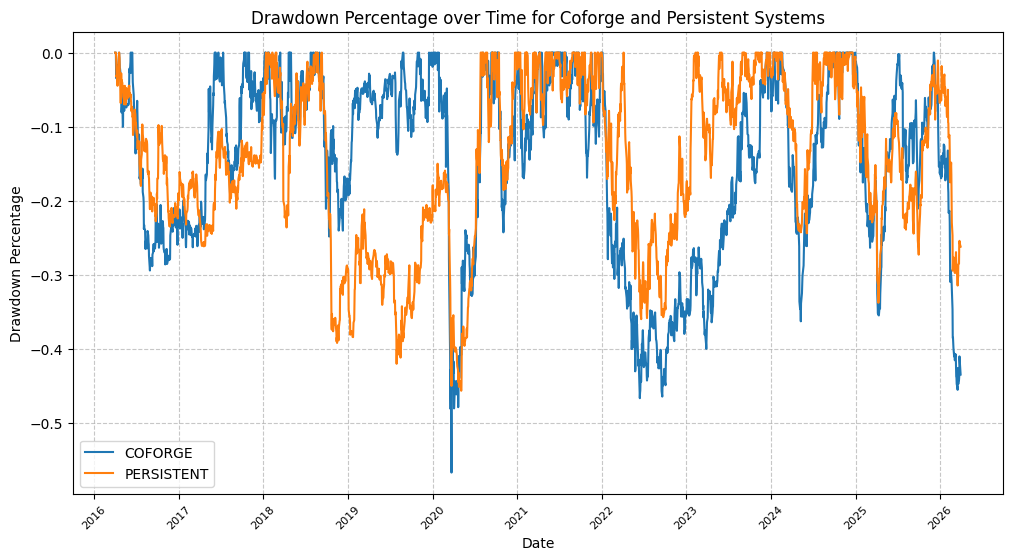

In [20]:
plt.figure(figsize = (12,6))

for ticker in compare_tickers:
  company_name = ticker.split('.')[0]
  sns.lineplot(x= compare_stock_df.index, y= compare_stock_df[f'Drawdown_{company_name}'], label= company_name)

plt.title('Drawdown Percentage over Time for Coforge and Persistent Systems')
plt.xlabel('Date')
plt.ylabel('Drawdown Percentage')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.xticks(rotation=45, fontsize=8)
plt.show()

The high maximum drawdown (mdd) is because of pandemic. Other than that, Coforge's lowest is below 0.5 and Persistent is less than 0.4. And in the current year Presistent is show a drawdown of around 0.3.

From this we can clearly say that Persistent's stock fall is not that significant compare to Coforge.

#### CAGR Calculation

In [21]:
for ticker in compare_tickers:
    company_name = ticker.split('.')[0]
    # Get the first and last non-NaN close prices
    first_close = compare_stock_df[ticker].iloc[0]
    last_close = compare_stock_df[ticker].iloc[-1]

    # Calculate the number of years. Data is from 2016-04-01 to 2026-03-31, approx 10 years.
    # More precisely, we can calculate the difference in years
    num_years = (compare_stock_df.index.max() - compare_stock_df.index.min()).days / 365.25

    # CAGR formula: (Ending Value / Beginning Value)^(1 / Number of Years) - 1
    cagr = ((last_close / first_close)**(1 / num_years)) - 1
    print(f"CAGR for {company_name}: {cagr * 100:.2f}%")

    # Store CAGR values to be used in the final results table
    if company_name == 'COFORGE':
        cagr_coforge = cagr
    elif company_name == 'PERSISTENT':
        cagr_per = cagr

CAGR for COFORGE: 29.21%
CAGR for PERSISTENT: 30.82%


CAGR of 29.19% and 30.79% for Coforge and Persistent, indicates a high-growth performance.

#### Beta Calculation

Beta is a measure of a stock's volatility in relation to the overall market. A beta of 1 indicates that the stock's price activity is strongly correlated with the market. A beta greater than 1 means the stock is more volatile than the market, while a beta less than 1 suggests it's less volatile.

In [22]:
# Extract market returns (NIFTY50)
daily_returns = nifty50_sector_df_filled.pct_change().dropna()
market_returns = daily_returns['^NSEI']

# Prepare a DataFrame with all necessary returns for beta calculation
beta_df = pd.DataFrame({
    'Market_Returns': market_returns,
    'COFORGE_Returns': compare_stock_df['Returns_COFORGE'],
    'PERSISTENT_Returns': compare_stock_df['Returns_PERSISTENT']
}).dropna()

# Calculate Beta for COFORGE
cov_coforge = beta_df['COFORGE_Returns'].cov(beta_df['Market_Returns'])
var_market = beta_df['Market_Returns'].var()
beta_coforge = cov_coforge / var_market

# Calculate Beta for Persistent Systems
cov_persistent = beta_df['PERSISTENT_Returns'].cov(beta_df['Market_Returns'])
beta_persistent = cov_persistent / var_market

print(f"Beta for Coforge: {beta_coforge:.4f}")
print(f"Beta for Persistent Systems: {beta_persistent:.4f}")

Beta for Coforge: 1.0617
Beta for Persistent Systems: 0.6860


Persistent's beta of 0.69 means it moves only 69% as much as the Nifty50 — a defensive characteristic. Coforge's beta of 1.06 means it slightly amplifies market movements, increasing both upside and downside exposure.

## Conslusion

In [23]:
risk_free_rate = 0.0691
trading_days_per_year = 252

# Calculate metrics for COFORGE
annual_return_coforge = compare_stock_df['Returns_COFORGE'].mean() * trading_days_per_year
vol_coforge = compare_stock_df['annualized_volatility_COFORGE'].mean()
sharpe_coforge = (annual_return_coforge - risk_free_rate) / vol_coforge if vol_coforge != 0 else 0
mdd_coforge = compare_stock_df['Drawdown_COFORGE'].min()

# Calculate metrics for Persistent Systems
annual_return_per = compare_stock_df['Returns_PERSISTENT'].mean() * trading_days_per_year
vol_per = compare_stock_df['annualized_volatility_PERSISTENT'].mean()
sharpe_per = (annual_return_per - risk_free_rate) / vol_per if vol_per != 0 else 0
mdd_per = compare_stock_df['Drawdown_PERSISTENT'].min()

results = pd.DataFrame({
    'Metric': ['Annual Return (%)', 'Annual Volatility (%)', 'Sharpe Ratio', 'Beta', 'Max Drawdown (%)', 'CAGR (%)'],
    'COFORGE': [
        annual_return_coforge * 100,
        vol_coforge * 100,
        sharpe_coforge,
        beta_coforge,
        mdd_coforge * 100,
        cagr_coforge * 100
    ],
    'Persistent': [
        annual_return_per * 100,
        vol_per * 100,
        sharpe_per,
        beta_persistent,
        mdd_per * 100,
        cagr_per * 100
    ]
})

print("--- FINAL QUANTITATIVE COMPARISON (2016-2026) ---")
display(results.set_index('Metric'))

--- FINAL QUANTITATIVE COMPARISON (2016-2026) ---


,COFORGE,Persistent
Metric,,
Annual Return (%),34.016237,33.054395
Annual Volatility (%),36.314687,31.910251
Sharpe Ratio,0.746426,0.819310
Beta,1.061717,0.686023
Max Drawdown (%),-56.758075,-45.698195
CAGR (%),29.213433,30.817767


After a 10-year comparative analysis (2016–2026), Persistent Systems is selected as the superior investment choice over Coforge based on the following quantitative evidence:

*   Within the broader IT sector identified as the top performer in our macro analysis, Persistent Systems is the optimal stock selection, delivering higher compounded growth with lower volatility, superior downside protection, and below-market systematic risk.

*   Superior Risk-Adjusted Returns: Persistent Systems achieved a higher Sharpe
Ratio (0.82 vs. 0.75). This indicates that for every unit of risk taken, Persistent generated more efficient returns than Coforge.

*   Lower Volatility & Stability: Despite being in the same high-growth bracket, Persistent demonstrated lower Annual Volatility (31.9% vs. 36.3%), meaning its daily price swings were meaningfully less severe..

*   Stronger Capital Protection: Persistent proved more resilient during market
stress, with a Maximum Drawdown of -45.7%, compared to the much deeper -56.7% seen in Coforge. An investor in Persistent avoided an additional 11% of peak-to-trough losses.

*   Lower Systematic Risk (Beta): Persistent’s Beta of 0.69 suggests it is less sensitive to broad market swings than Coforge (Beta of 1.06), offering better diversification for a portfolio.

*   Compound Growth (CAGR): Ultimately, Persistent delivered a higher CAGR (30.8% vs. 29.2%), proving that its "smoother" ride actually resulted in more total wealth over the long term.

Final Verdict: Persistent Systems is the optimal choice as it delivered higher compounded growth with lower volatility and superior downside protection.